# Population genetic simulaion with phenotypic noise

In [2]:
import hanoi
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
%matplotlib inline

# How to represent data

## Basic parameters

Population size $N$

In [3]:
N = 18
print(N)

18


Number of traits $n$

In [4]:
n = 2

Number of loci L

In [5]:
L = 5

## Mutation effect

### Phenotypic mean

Effect of allele `1` at $L$  loci on **mean (phenotypic expectation)** of $n$ traits compared to allele `0` is represented in $M_m$, a 2D array ($n \times L$) 

$M_m = 
\begin{pmatrix}
\mu_{1(0,0)} & \mu_{1(0,1)} & ... & \mu_{1,(0,L-1)}\\
\mu_{1(1,0)} & \mu_{1(1,1)} & ... & \mu_{1,(1,L-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & \mu_{1(j,l)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
\mu_{1(n-1,0)} & \mu_{1(n-1,1)} & ... & \mu_{1,(n-1,L-1)}\\
\end{pmatrix}
$

In [6]:
M_m = np.array([[1, 0, 0, 0, 0], 
                [0, 1, 0, 0, 0]],
               dtype = np.float64
               )
print(M_m)

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


In this scenario, allele `1` of locus 0 increases phenotype of trait 1 by 1.0, and allele `1` of locus 1 increases the phenotype of trait 2 by 1.0

### Phenotypic variance

Effect of allele `1` at $L$  loci on **variance (phenotypic noise)** of $n$ traits compared to allele `0` is represented in $M_v$, a 2D array ($n \times L$) 

$M_v = 
\begin{pmatrix}
\sigma^2_{1(0,0)} & \sigma^2_{1(0,1)} & ... & \sigma^2_{1,(0,L-1)}\\
\sigma^2_{1(1,0)} & \sigma^2_{1(1,1)} & ... & \sigma^2_{1,(1,L-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & \sigma^2_{1(j,l)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
\sigma^2_{1(n-1,0)} & \sigma^2_{1(n-1,1)} & ... & \sigma^2_{1,(n-1,L-1)}\\
\end{pmatrix}
$

In [7]:
M_v = np.array([[0, 0, 0.01, 0, 0], 
                [0, 0, 0, 0.01, 0]],
               dtype = np.float64
               )
print(M_v)

[[0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]]


In this scenario, allele `1` of locus 2 increases the variance of trait 1 by 0.01 (so increase SD by 0.1), and allele `1` of locus 3 increases the variance of trait 2 by 0.01.

### Phenotypic covariance

Effect of allele `1` at $L$  loci on **covariance ((in)dependence of development among traits)** of $\binom{n}{2}$ traits compared to allele `0` is represented in $M_v$, a 2D array ($\binom{n}{2} \times L$) 

$M_c = 
\begin{pmatrix}
cov_{1((0,1), 0)} & cov_{1((0,1), 1)} & ... & cov_{1((0,1), L-1)}\\
cov_{1((0,2), 0)} & cov_{1((0,2), 1)} & ... & cov_{1((0,2), L-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & cov_{1((j,k),l)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
cov_{1((n-2,n-1), 0)} & cov_{1((n-2,n-1), 1)} & ... & cov_{1((n-2,n-1), L-1)}
\end{pmatrix}
$

In [8]:
M_c = np.array([[0, 0, 0, 0, -0.009]],
               dtype = np.float64
               )
print(M_c)

[[ 0.     0.     0.     0.    -0.009]]


In this scenario, allele `1` of locus 4 reduces the covariance between trait 1 and trait 2 by 0.0009.

Note when $n = 1$, $M_c$ is empty, with 0 rows

Note for now I am assuming that each locus has one effect.
In other words, I assume **no pleiotropy between traits**, and **no expectation-noise dependence**.

In [8]:
np.concatenate((M_m, M_v, M_c), axis = 0)

array([[ 1.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  1.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.01 ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.01 ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   , -0.009]])

### hanoi.MutEffect

In `hanoi`, mutation effects of loci on traits are represented by objects of `MutEffect` type.

In [9]:
hanoi.MutEffect?

Init signature:
hanoi.MutEffect(
    mean: numpy.ndarray,
    var: numpy.ndarray,
    cov: numpy.ndarray,
)
Docstring:     
A class to represent mutational effects on mean, variance, and covariance of traits.

Attributes
----------
mean : Mean effects. 
    Should be a 2D np.array of shape (n, L). 
    mean[i, j] holds the effect of allele 1 at locus j on trait i.
var : Variance effects.
    Should be a 2D np.array of shape (n, L).
    var[i, j] holds the effect of allele 1 at locus j on trait i.
cov : Covariance effects.
    Should be a 2D np.array of shape (choose(n, 2), L).
    cov[i, j] holds the effect of allele 1 at locus j on the i-th trait pair.
n : Number of traits
L : Number of loci


Methods
-------
show() : Prints information of the MutEffect object.
File:           ~/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:           type
Subclasses:     

In [10]:
M = hanoi.MutEffect(mean = M_m, var = M_v, cov = M_c)
M.show()

Number of traits n:
2
Number of trait pairs:
1
Number of loci L:
5
Mutation effect of mean:
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
Mutation effect of variance:
[[0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]]
Mutation effect of covariance:
[[ 0.     0.     0.     0.    -0.009]]


## Genotype

The genotypes of $N$ diploid individuals at $L$ loci are represented as a matrix of $(L, N)$ (like VCF).

$G = 
\begin{pmatrix}
g_{0,0} & g_{0, 1} & ... & g_{0, N-1}\\
g_{1,0} & g_{1, 1} & ... & g_{1, N-1}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & g_{l,i} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
g_{L-1,0} & g_{L-1, 1} & ... & g_{L-1, N-1}\\
\end{pmatrix}
$

$g_{l,i} \in \{0, 1, 2\}$

In [11]:
G = np.zeros((L, N), dtype = np.float64)
G

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]])

In [12]:
for i in range(L):
    G[i, 2*i:2*(i+1)]  = 0
    G[i, 2*(i+1):2*(i+2)] = 1
    G[i, 2*(i+2):2*(i+3)] = 2
G[:, 14:16] = 1
G[:, 16:18] = 2
G

array([[0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 1., 1.,
        2., 2.]])

In [13]:
G.shape

(5, 18)

# How to simulate one generation

## Breeding value (Genetic value)

Based on the **mutation effects** and **genotype**, multivariate **breeding value** is computed for each of the $N$ individuals.
Just as mutation effects, the breeding value in my model consists of three components: mean of $n$ traits, variance (size of phenotypic noise) of $n$ traits), and covariance (dependence) of between $\binom{n}{2}$ pairs of $n$ traits.

### Breeding value of mean (phenotypic expectation)

**Breeding values of mean** of $n$ traits of $N$ individuals are represented by $A_m$, a matrix of $(n, N)$.
Breeding value of each individual is simply the sum of effects of allele 1 at all loci.

$
A_m = 
\begin{pmatrix}
a_{m(0,0)} & a_{m(0,1)} & ... & a_{m(0,N-1)}\\
a_{m(1,0)} & a_{m(1,1)} & ... & a_{m(1,N-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & a_{m(j,i)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
a_{m(n,0)} & a_{m(n,1)} & ... & a_{m(n,N-1)}\\
\end{pmatrix} = \dfrac{1}{2} M_m G
$

$a_{m(j,i)} = \sum_\limits{l=0}^{L-1}{\frac{1}{2} \mu_{1(j,l)} g_{l,i} }$

### Breeding value of variance (phenotypic noise)

Similarly, **breeding values of variance** of $n$ traits of $N$ individuals are represented by $A_v$.

$
A_v = 
\begin{pmatrix}
a_{v(0,0)} & a_{v(0,1)} & ... & a_{v(0,N-1)}\\
a_{v(1,0)} & a_{v(1,1)} & ... & a_{v(1,N-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & a_{v(j,i)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
a_{v(n-1,0)} & a_{v(n-1,1)} & ... & a_{v(n-1,N-1)}\\
\end{pmatrix} = \dfrac{1}{2} M_v G
$

$a_{v(j,i)} = \sum_\limits{l=0}^{L-1}{\frac{1}{2} \sigma^2_{1(j,l)} g_{l,i} }$

### Breeding value of covariance (developmental dependence between traits)

And **breeding values of covariance** of $\binom{n}{2}$ pairs of traits of $N$ individuals are represented by $A_c$

$
A_c = 
\begin{pmatrix}
a_{c((0,1),0)} & a_{c((0,1),1)} & ... & a_{v((0,1),N-1)}\\
a_{c((0,2),0)} & a_{c((0,2),1)} & ... & a_{v((0,2),N-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & a_{c((j,k),i)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
a_{c((n-2,n-1),0)} & a_{c((n-2,n-2),1)} & ... & a_{c(n-2,n-1),N-1)}\\
\end{pmatrix} = \dfrac{1}{2} M_c G
$

$j \ne k$

$a_{c((j,k),i)} = \sum_\limits{l=0}^{L-1}{\frac{1}{2} cov_{1((j,k),l)} g_{l,i} }$

### Implementation of breeding value in `hanoi`

This structure of breeding value can be represented in an object of `hanoi.BreedVal` type.

In [14]:
hanoi.BreedVal??

Init signature: hanoi.BreedVal(mean: numpy.ndarray, var: numpy.ndarray, cov: numpy.ndarray)
Docstring:      <no docstring>
Source:        
class BreedVal:
    def __init__(self, mean: np.ndarray, var: np.ndarray, cov: np.ndarray):
        self.mean = mean
        self.var = var 
        self.cov = cov 
        self.N = mean.shape[1]
        self.n = mean.shape[0]
        if self.n == 1:
            self.varcov = np.empty((0, self.N))
        else:
            self.varcov = np.array([cov_mtx(var = self.var[:,i], cov = self.cov[:,i]) for i in range(self.N)])
        for arr in (self.var, self.cov):
            if arr.ndim != 2:
                raise ValueError("mean, var, and cov must be 2D arrays.")
        Ns = [self.var.shape[1], self.cov.shape[1]]
        if not all(N == self.N for N in Ns):
            raise ValueError("mean, var, and cov must have the same number of columns (N)")
        if self.n != var.shape[0]:
            raise ValueError("mean and var must have the same number

`hanoi.BreedVal` can be computed from the genotype (`np.ndarray`)and mutation effects (`hanoi.MutEffect`) using `hanoi.comp_breed_val()` function.

In [15]:
hanoi.comp_breed_val??

Signature:
hanoi.comp_breed_val(
    mut_effect: hanoi.hanoi.MutEffect,
    genotype: numpy.ndarray,
)
Docstring: <no docstring>
Source:   
def comp_breed_val(mut_effect: MutEffect, genotype: np.ndarray):
    A_m = 1/2 * mut_effect.mean @ genotype
    A_v = 1/2 * mut_effect.var @ genotype
    A_c = 1/2 * mut_effect.cov @ genotype
    return BreedVal(mean = A_m, var = A_v, cov = A_c)
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:      function

In [16]:
A = hanoi.comp_breed_val(mut_effect = M, genotype = G)

In [17]:
A.show()

Number of traits:
 2
Number of trait pairs:
 1
Number of individuals:
 18
Breeding value of mean:
 [[0.  0.  0.5 0.5 1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.5 1.  1. ]
 [0.  0.  0.  0.  0.5 0.5 1.  1.  0.  0.  0.  0.  0.  0.  0.5 0.5 1.  1. ]]
Breeding value of variance:
 [[0.    0.    0.    0.    0.    0.    0.005 0.005 0.01  0.01  0.    0.
  0.    0.    0.005 0.005 0.01  0.01 ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.005 0.005 0.01  0.01
  0.    0.    0.005 0.005 0.01  0.01 ]]
Breeding value of covariance:
 [[ 0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.     -0.0045 -0.0045 -0.009  -0.009  -0.0045 -0.0045 -0.009  -0.009 ]]
Breeding value of variance-covariance:
 [[[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.005   0.    ]
  [ 0.   

## Phenotype

The phenotype $z_i$ of individual $i$ is sampled from a **multivariate normal distribution**, whose parameter specific to individual $i$ is based on the breeding value. 

$z_{i} = 
\begin{pmatrix}
z_{i(0)}\\
z_{i(1)}\\
\vdots\\
z_{i(n-1)}\\
\end{pmatrix}
\sim \mathcal{N}(z_\mathrm{ref} + A_{m(i)}, c_\mathrm{ref} + A_{vc(i)})$

where

$z_\mathrm{ref} = 
\begin{pmatrix}
z_{\mathrm{ref}(0)}\\
z_{\mathrm{ref}(1)}\\
\vdots\\
z_{\mathrm{ref}(n-1)}\\
\end{pmatrix}
$

$c_\mathrm{ref}=
\begin{pmatrix}
\sigma^2_\mathrm{ref(0)} & cov_\mathrm{ref(0,1)} & ... & cov_\mathrm{ref(0,n-1)}\\
cov_\mathrm{ref(1,0)} & \sigma^2_\mathrm{ref(1)} &  ... & cov_\mathrm{ref(1,n-1)}\\
\vdots & \vdots & & \vdots \\
cov_\mathrm{ref(n-1,0)} &   cov_\mathrm{ref(n-1,1)} &... & \sigma^2_\mathrm{ref(n-1)} \\
\end{pmatrix}
$

and

$A_{m(i)} = 
\begin{pmatrix}
a_{m(i,0)}\\
a_{m(i,1)}\\
\vdots\\
a_{m(i,n-1)}
\end{pmatrix}$

$A_{vc(i)} = 
\begin{pmatrix}
a_{v(0,i)} & a_{c((0,1),i)} & ... & a_{c((0,n-1),i)}\\
a_{c((1,0),i)} & a_{v(1,i)} & ... & a_{c((1,n-1),i)}\\
\vdots & \vdots & &  \vdots\\
a_{c((n-2, 0),i)} & a_{c((n-2, n-1),i)} & ... & a_{v(n-1, i)}
\end{pmatrix}$

For the demonstration, I assume

$z_\mathrm{ref} =
\begin{pmatrix}
0\\
0
\end{pmatrix}
$

$c_\mathrm{ref} = 
\begin{pmatrix}
0.01 & 0\\
0 & 0.01
\end{pmatrix}
$

In [18]:
z_ref = np.array([0,0], dtype = np.float64)
c_ref = np.array([[0.01,0.00],
                  [0.00,0.01]], dtype = np.float64)

In [19]:
print(z_ref)

[0. 0.]


In [20]:
print(c_ref)

[[0.01 0.  ]
 [0.   0.01]]


Simulation of phenotypes is implemented in `hanoi.sim_pheno()` function.

In [21]:
hanoi.sim_pheno?

Signature: hanoi.sim_pheno(breed_val: hanoi.hanoi.BreedVal, mean_0, varcov_0)
Docstring: <no docstring>
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/simulate.py
Type:      function

In [22]:
z = hanoi.sim_pheno(breed_val = A, mean_0 = z_ref, varcov_0 = c_ref)

In [23]:
z

array([[-0.21428718,  0.11070619],
       [-0.02934768,  0.05742905],
       [ 0.59180873,  0.0575049 ],
       [ 0.66053655, -0.18901147],
       [ 0.99519408,  0.58925268],
       [ 1.15398673,  0.51777393],
       [ 0.0975109 ,  0.76544681],
       [-0.00883968,  1.19073484],
       [-0.23374279,  0.064635  ],
       [ 0.10046804,  0.13974218],
       [-0.03862704,  0.0756462 ],
       [-0.02257634, -0.0200504 ],
       [ 0.15784541, -0.12075225],
       [ 0.06161109, -0.08106266],
       [ 0.20659805,  0.34013211],
       [ 0.53237403,  0.54244373],
       [ 1.12518698,  0.76379269],
       [ 0.99450897,  0.98884353]])

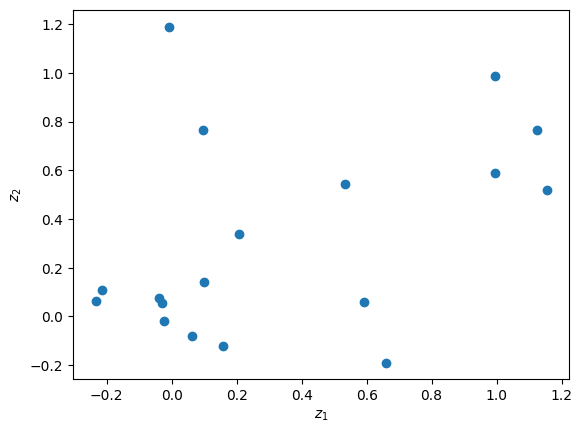

In [24]:
plt.scatter(z[:,0], z[:,1])
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def plot_bivariate_normal_contour(mean, cov, percentile=0.95, ax=None, **ellipse_kwargs):
    """
    Plots the contour of a bivariate normal distribution for a given percentile.

    Parameters:
        mean : array-like of shape (2,)
            Mean of the distribution.
        cov : array-like of shape (2,2)
            Covariance matrix.
        percentile : float
            Probability mass to enclose (default 0.95).
        ax : matplotlib Axes, optional
            Axes to draw on. If None, creates a new figure.
        ellipse_kwargs : additional kwargs for matplotlib.patches.Ellipse
            e.g., edgecolor, facecolor, linewidth, label
    """
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]  # descending
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Rotation angle of ellipse
    angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))

    # Chi-square scaling for desired percentile
    s = chi2.ppf(percentile, df=2)

    # Width and height
    width, height = 2 * np.sqrt(eigvals * s)

    # Create plot if needed
    if ax is None:
        fig, ax = plt.subplots()

    # Draw ellipse
    ellipse = Ellipse(mean, width=width, height=height, angle=angle, **ellipse_kwargs)
    ax.add_patch(ellipse)
    
    return ax

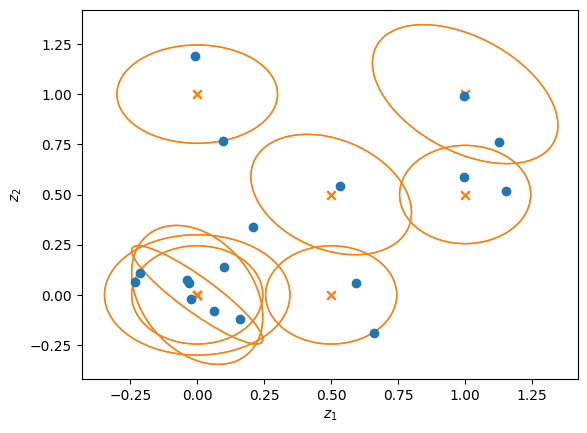

In [26]:
fig, ax = plt.subplots()
#ax.scatter(A.mean.T[:,0], A.mean.T[:,1])
ax.scatter(A.mean.T[:,0], A.mean.T[:,1], color = 'tab:orange', marker = 'x')

for i in range(len(A.mean.T)):
    plot_bivariate_normal_contour(mean = z_ref + A.mean[:,i], cov = c_ref + A.varcov[i], percentile=0.95, ax=ax, facecolor = 'none', edgecolor = "tab:orange")
    
ax.scatter(z[:,0], z[:,1], color = 'tab:blue')

plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()

## Fitness functions

I implemented four kinds of fitness functions

### Neutral

In [27]:
hanoi.fit_neutral(z)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1.])

### Gaussian fitness function

In [28]:
hanoi.fit_gaus?

Signature: hanoi.fit_gaus(sigma, z_opt, z)
Docstring:
sigma: A scalar specifying SD around the peak
z_opt: (n,) array specifying the coordinate of the peak in the n dimensional phenotypic space
z:      (N, n) array representing n-dimensional phenotypes of N individuals.
Returns: (N,) array representing fitness of N individuals
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/fitness.py
Type:      function

For one trait

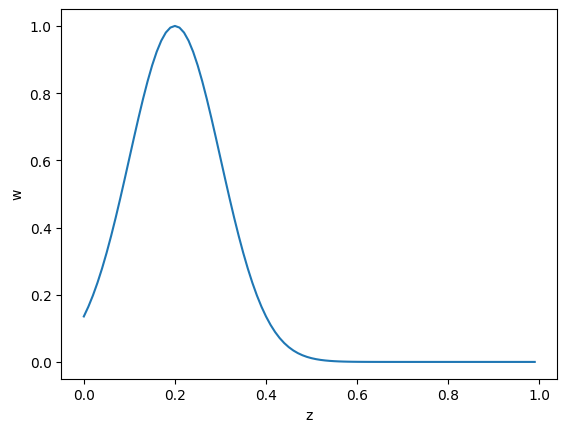

In [37]:
z_1D = np.arange(100, dtype = np.float64)/100
w1 = hanoi.fit_gaus(z_opt = np.array([0.2], dtype = np.float64), 
                    sigma = 0.1,
                    z = z_1D
                   )
plt.plot(z_1D, w1)
plt.xlabel("z")
plt.ylabel("w")
plt.show()

For 2 traits

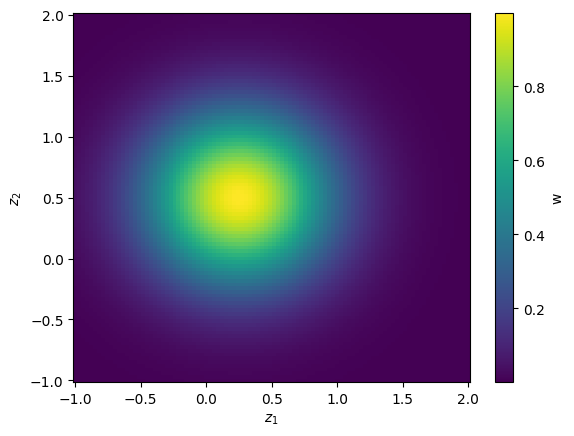

In [38]:
# Make meshgrid
X, Y = np.meshgrid(np.linspace(-1,2,100), np.linspace(-1,2,100))

# Flatten to feed into fit_gaus
z2 = np.column_stack([X.ravel(), Y.ravel()])

# Evaluate w2
w2_g = hanoi.fit_gaus(z_opt=np.array([0.25, 0.5], dtype=np.float64),
                    sigma=0.5,
                    z=z2)

# Reshape to grid for pcolormesh
w2_g_grid = w2_g.reshape(100, 100)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()


We can apply this 2D Gaussian fitness function to the 2D traits

In [40]:
w = hanoi.fit_gaus(z_opt = np.array([0.25,0.5], dtype = np.float64),
                 sigma = 0.5,
                 z = z
                )

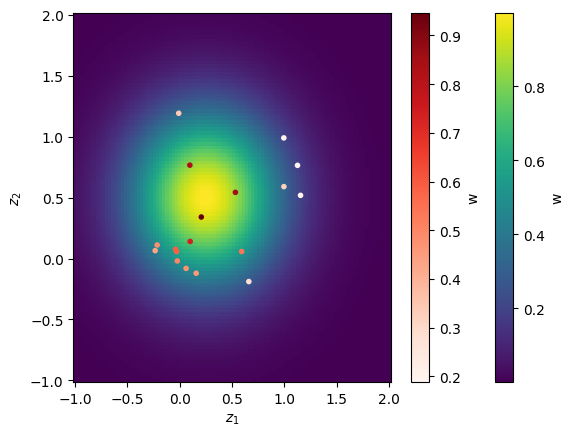

In [41]:
fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c=w,  cmap='Reds', marker = '.')

plt.colorbar(label='w')
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()

### Multimodal fitness function

For one trait

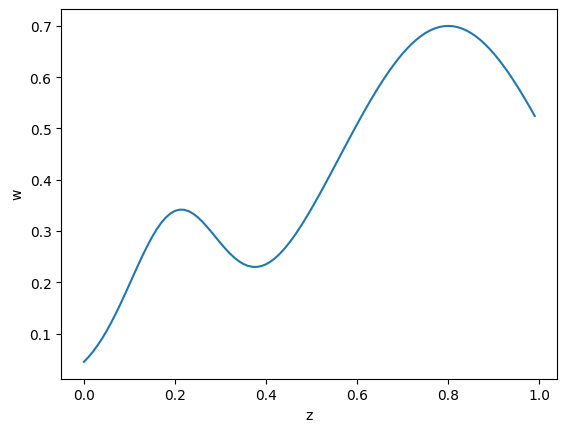

In [42]:
w1_m = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.3, 0.7]), 
                            z_opt = np.array([[0.2],[0.8]]), 
                            z = z_1D
                           )
plt.plot(z_1D, w1_m)
plt.xlabel("z")
plt.ylabel("w")
plt.show()

For 2D trait

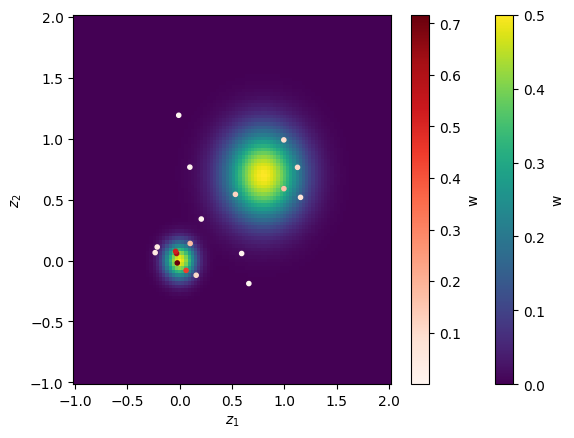

In [43]:
w2_m = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.5, 0.5]), 
                            z_opt = np.array([[0,0],[0.8,0.7]]), 
                            z = z2
                           )
w = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.75, 0.25]), 
                            z_opt = np.array([[0,0],[0.8,0.7]]), 
                            z = z
                           )


# Reshape to grid for pcolormesh
w2_m_grid = w2_m.reshape(100, 100)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_m_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c = w, cmap = 'Reds', marker = '.')
plt.colorbar(label="w")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()

### Step fitness function

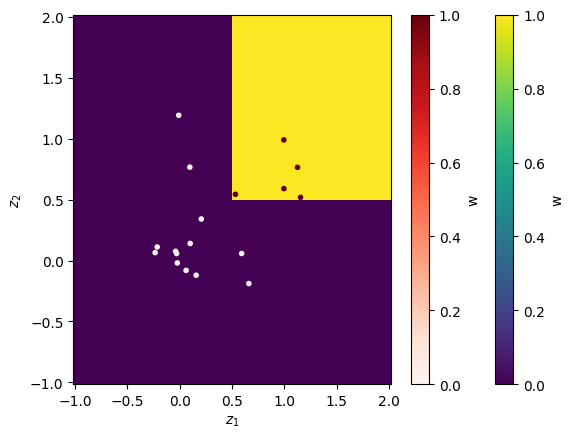

In [44]:
w2_s = hanoi.fit_step(z = z2, boxes = np.array([[[0.5, 0.5], [np.inf, np.inf]]]))
w = hanoi.fit_step(z = z, boxes = np.array([[[0.5, 0.5], [np.inf, np.inf]]]))

# Reshape to grid for pcolormesh
w2_s_grid = w2_s.reshape(100, 100)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_s_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c = w, cmap = 'Reds', marker = '.')
plt.colorbar(label="w")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()



## Mutation

Germline mutation is simulated.

I assume that mutation occurs after development of phenotype (or independent of phenotype) and before meiosis.

When mutation rate is $u$ \[per locus per generation\], the probability for a diploid genotype $i$ to change into $j$ is described by $p_u(i,j)$ of a transition matrix $p_u$

$p_u =
\begin{pmatrix}
(1 - u)^2 & 2 u (1 - u) & u^2\\
u (1 - u) & (1 - u)^2 + u^2 & u  (1 - u)\\
u^2 & 2 u (1 - u) & (1 - u)^2
\end{pmatrix}$

In `hanoi`, this is implemented in `hanoi.sim_mutation()` function.

In [45]:
hanoi.sim_mutation?

Signature: hanoi.sim_mutation(genotype, mut_rate)
Docstring: <no docstring>
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/simulate.py
Type:      function

In [46]:
G

array([[0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 1., 1.,
        2., 2.]])

In [47]:
G_mut = hanoi.sim_mutation(genotype = G, mut_rate = 0.1)
G_mut

array([[0., 0., 1., 2., 2., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 1.],
       [0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 2., 1.,
        1., 2.],
       [0., 0., 0., 1., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 1.,
        2., 2.],
       [0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 1., 1.,
        2., 2.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 2., 1., 1.,
        1., 2.]])

In [48]:
G == G_mut

array([[ True,  True,  True, False,  True, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True, False,  True, False,  True],
       [ True,  True,  True, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True, False,  True,  True,  True],
       [ True, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False, False,  True,  True,  True, False,  True]])

## Reproduction

$N$ individuals of offspring have $2N$ haploid genomes.

For one haploid genome of offspring, the probability $p_i$ that an individual $i$ is the parent is its fitness relative to the total fitness of all individuals

$p_i = \dfrac{W_i}{N\overline{W}} = \dfrac{W_i}{\sum_\limits{j=0}^{L-1}{W_j}}$

The joint distribution of the number of offspring $N_i'$ of $N$ individuals ($i \in \{0, 1, ..., N-1\}$) follows a **multinomial distribution**.

$(N_0', N_1', ..., N_{N-1}') \sim \mathrm{multinom}(p_0, p_1, ..., p_{N-1})$

where $\sum_\limits{i=0}^{N-1}{N_i'} = 2N$ and $\sum_\limits{i=0}^{N-1}{p_i} = 1$

Each of $N$ individuals of offspring will have two parents randomly picked from the multinomial variable.

This sampling representing reproduction according to fitness is implemented in `hanoi.sim_reproduction()` function.

In [49]:
hanoi.sim_reproduction??

Signature: hanoi.sim_reproduction(popsize, genotype, fitness)
Docstring: <no docstring>
Source:   
def sim_reproduction(popsize, genotype, fitness ):
    # number of offspring per genotype of each genotype
    n_loci = genotype.shape[0]
    if fitness.sum() == 0:
        genotype_next = np.full((n_loci, popsize), np.nan)
        n_offspring = np.zeros(popsize, dtype = int)
        #raise RuntimeError("Fitness of all individuals is 0")
        return genotype_next, n_offspring
    n_offspring = np.random.multinomial(n = 2 * popsize, pvals = fitness/fitness.sum())

    # index of 2N parents
    sam = np.repeat(range(popsize), n_offspring)
    # Shuffle the 2N parents
    np.random.shuffle(sam)
    # Reshape parents so that they are in pairs
    sam = sam.reshape(popsize, 2)
    # Mating
    genotype_next = np.random.binomial(1, genotype[:,sam]/2 ).sum(axis = 2)
    return genotype_next, n_offspring
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/simulate.py
Type:      func

`hanoi.sim_reproduction()` returns a tuple of two:

1. genotype matrix of the offspring
2. number of offspring of each individual

### e.g. Gaussian fitness function

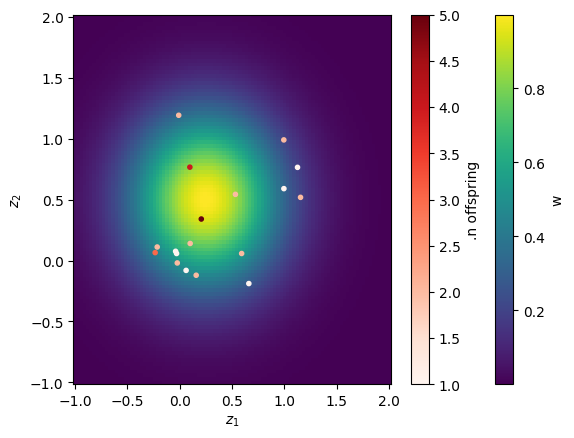

In [50]:
w = hanoi.fit_gaus(z_opt = np.array([0.25,0.5], dtype = np.float64),
               sigma = 0.5,
               z = z
              )
G_next, n_offspring = hanoi.sim_reproduction(popsize = N, genotype = G, fitness = w)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c=n_offspring,  cmap='Reds', marker = '.')

plt.colorbar(label='.n offspring')
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()

In [ ]:
G_next

### e.g. Multinomial fitness function

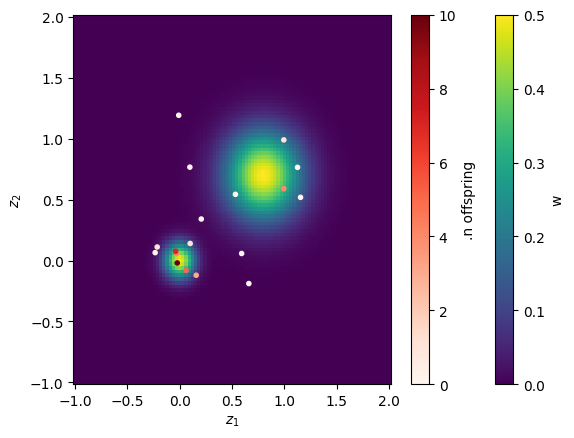

In [51]:
w = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.75, 0.25]), 
                            z_opt = np.array([[0,0],[0.8,0.7]]), 
                            z = z
                           )
G_next, n_offspring = hanoi.sim_reproduction(popsize = N, genotype = G, fitness = w)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_m_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c=n_offspring,  cmap='Reds', marker = '.')

plt.colorbar(label='.n offspring')
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()

### e.g. Step fitness function

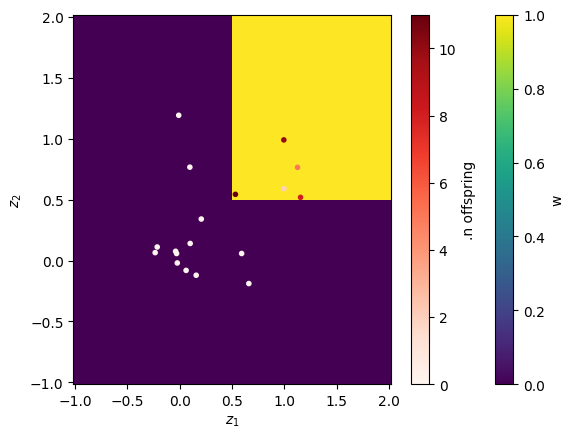

In [52]:
w = hanoi.fit_step(z = z, boxes = np.array([[[0.5, 0.5], [np.inf, np.inf]]]))
G_next, n_offspring = hanoi.sim_reproduction(popsize = N, genotype = G, fitness = w)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_s_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c=n_offspring,  cmap='Reds', marker = '.')

plt.colorbar(label='.n offspring')
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()

## `hanoi.Generation` class

The info about mutation effect, genotypes, breeding values, fitness, number of offspring, genotype of the next generation can be put in one object of `hanoi.Generation` class.

In [53]:
hanoi.Generation?

Init signature:
hanoi.Generation(
    genotype: numpy.ndarray,
    genotype_next: numpy.ndarray,
    breed_val: hanoi.hanoi.BreedVal,
    phenotype: numpy.ndarray,
    fitness: numpy.ndarray,
    n_offspring: numpy.ndarray,
)
Docstring:      <no docstring>
File:           ~/Dropbox/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:           type
Subclasses:     Generations

## `hanoi.sim_generation()`

Simulation of one cycle of generation is implemented in `hanoi.sim_generation()` function.

In [54]:
hanoi.sim_generation?

Signature:
hanoi.sim_generation(
    mut_effect,
    genotype,
    mut_rate,
    fit_func,
    mean_0,
    varcov_0,
    **kwargs,
)
Docstring: <no docstring>
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/simulate.py
Type:      function

In [55]:
gen = hanoi.sim_generation(mut_effect = M, 
                           genotype = G, 
                           mut_rate = 0,
                           mean_0 = z_ref,
                           varcov_0 = c_ref,
                           fit_func = "fit_gaus",
                           z_opt = np.array([0.25,0.5]),
                           sigma = 0.5
                          )

You can access the information in attributes such as numer of offspring of N individuals, and genotype of the offspring

In [56]:
gen.n_offspring

array([2, 2, 0, 2, 0, 1, 2, 4, 2, 3, 4, 2, 2, 0, 3, 5, 2, 0])

In [57]:
gen.genotype_next

array([[1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 2, 2, 0, 1],
       [0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 2, 1],
       [0, 2, 1, 1, 2, 0, 1, 2, 1, 1, 1, 0, 2, 0, 0, 1, 2, 0],
       [1, 0, 1, 0, 2, 1, 0, 1, 1, 0, 1, 1, 1, 2, 0, 1, 0, 0],
       [0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 2, 0, 0]])

Allele frequencies in the parents and offspring can be obtained with `hanoi.Generation.allele_freqs()` and `hanoi.Generation.allele_freqs_next()` methods.

In [58]:
gen.allele_freqs()

array([[0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333]])

In [59]:
gen.allele_freqs_next()

array([[0.27777778, 0.30555556, 0.47222222, 0.36111111, 0.27777778]])

You can compute allele frequency change in one generation for all $L$ loci

In [60]:
gen.allele_freqs_next() - gen.allele_freqs()

array([[-0.05555556, -0.02777778,  0.13888889,  0.02777778, -0.05555556]])

# How to simulate multiple generations

You can simulate many generations recursively running `hanoi.sim_generation()` on returned genotype matrix.

This is implemented in `hanoi.sim_generations()` function.

In [61]:
hanoi.sim_generations?

Signature:
hanoi.sim_generations(
    n_gen,
    mut_effect,
    genotype,
    mut_rate,
    mean_0,
    varcov_0,
    fit_func,
    **kwargs,
)
Docstring: <no docstring>
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/simulate.py
Type:      function

In [75]:
gens = hanoi.sim_generations(n_gen = 0, 
                             mut_effect = M, 
                             genotype = G, 
                             mut_rate = 0.0,
                             mean_0 = z_ref,
                             varcov_0 = c_ref,
                             fit_func = "fit_gaus",
                             z_opt = np.array([0.25, 0.25]),
                             sigma = 0.25)

In [76]:
gens.n_gen

44

In [77]:
gens = hanoi.sim_generations(n_gen = 40, 
                             mut_effect = M, 
                             genotype = G, 
                             mut_rate = 0.0,
                             mean_0 = z_ref,
                             varcov_0 = c_ref,
                             fit_func = "fit_gaus",
                             z_opt = np.array([0.25, 0.25]),
                             sigma = 0.25)

In [78]:
gens.n_gen

40

`hanoi.sim_generations()` returns a `hanoi.Generations` object.

In [79]:
type(gens)

hanoi.hanoi.Generations

In [80]:
hanoi.Generations??

Init signature: hanoi.Generations(*args, n_gen, **kwargs)
Docstring:      <no docstring>
Source:        
class Generations(Generation):
    def __init__(self, *args, n_gen, **kwargs):
        super().__init__(*args, **kwargs)
        self.n_gen = n_gen
    def allele_freqs(self):
        #return np.array([genotype.mean(axis=1)/2 for genotype in generations.genotype_next])
        return np.array([genotype.mean(axis=1)/2 for genotype in self.genotype])
    def allele_freqs_next(self):
        #return np.array([genotype.mean(axis=1)/2 for genotype in generations.genotype_next])
        return np.array([genotype_next.mean(axis=1)/2 for genotype_next in self.genotype_next])
    def generation(self, t):
        return Generation(genotype = self.genotype[t], 
                          breed_val = self.breed_val[t], 
                          fitness = self.fitness[t], 
                          genotype_next = self.genotype_next[t], 
                          n_offspring = self.n_offspring[t

Allele frequency trajectory can be accessed with the `.allele_freqs()` method.

In [81]:
gens.allele_freqs()

array([[0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333],
       [0.11111111, 0.11111111, 0.27777778, 0.36111111, 0.22222222],
       [0.19444444, 0.08333333, 0.08333333, 0.19444444, 0.25      ],
       [0.08333333, 0.02777778, 0.19444444, 0.19444444, 0.19444444],
       [0.13888889, 0.02777778, 0.22222222, 0.13888889, 0.08333333],
       [0.16666667, 0.02777778, 0.08333333, 0.08333333, 0.05555556],
       [0.25      , 0.        , 0.08333333, 0.02777778, 0.08333333],
       [0.47222222, 0.        , 0.13888889, 0.13888889, 0.02777778],
       [0.36111111, 0.        , 0.25      , 0.25      , 0.05555556],
       [0.36111111, 0.        , 0.33333333, 0.22222222, 0.02777778],
       [0.11111111, 0.        , 0.44444444, 0.22222222, 0.        ],
       [0.25      , 0.        , 0.44444444, 0.25      , 0.        ],
       [0.19444444, 0.        , 0.41666667, 0.30555556, 0.        ],
       [0.13888889, 0.        , 0.5       , 0.30555556, 0.        ],
       [0.13888889, 0.        , 0.

Genotype, breeding value, phenotype, fitness, number of offspring of all generations can be accessed by `genotype`, `breed_val`, `fitness`, and `n_offspring` attributes. Each can be sliced for focal generation.

In [87]:
gens.genotype

array([[[0., 0., 1., ..., 1., 2., 2.],
        [0., 0., 0., ..., 1., 2., 2.],
        [0., 0., 0., ..., 1., 2., 2.],
        [0., 0., 0., ..., 1., 2., 2.],
        [0., 0., 0., ..., 1., 2., 2.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 1.],
        [1., 2., 0., ..., 0., 0., 1.],
        [0., 0., 1., ..., 0., 2., 0.]],

       [[0., 1., 0., ..., 2., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 1., 0., 0.],
        [1., 1., 1., ..., 0., 1., 1.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

  

Breeding value of mean ($A_m$) at generation 12

In [89]:
gens.breed_val[12].mean

array([[0.5, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. ,
        0.5, 0. , 0.5, 0.5, 0.5],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. ]])

Fitness every 5 generations

In [90]:
gens.fitness[range(0,gens.n_gen,5)]

array([[5.21803425e-01, 3.40918506e-01, 3.52452619e-01, 2.78071335e-01,
        1.38202578e-02, 3.14050201e-03, 5.53526021e-03, 9.05455269e-03,
        6.22370226e-01, 1.26936030e-01, 2.52081860e-01, 4.38324436e-01,
        3.57001309e-01, 2.59888058e-01, 2.01049813e-01, 1.44265595e-01,
        1.54029702e-03, 6.48587558e-06],
       [2.46954358e-01, 7.18643349e-01, 3.69974104e-01, 2.70018771e-01,
        1.24230013e-01, 6.29387239e-01, 6.58462849e-01, 3.65182201e-01,
        6.25802331e-01, 1.93058246e-01, 1.46043361e-01, 1.64088735e-01,
        2.56946803e-01, 4.17925183e-01, 5.57240999e-01, 5.14711468e-01,
        3.08306803e-01, 4.13472466e-01],
       [4.65513265e-01, 4.68557255e-01, 3.37292160e-01, 7.23617695e-01,
        2.27500671e-01, 3.86061351e-01, 6.63223595e-01, 2.02621768e-01,
        5.29893324e-01, 3.83244788e-01, 2.16571553e-01, 3.08173322e-01,
        1.07050494e-01, 4.64163302e-01, 1.73888167e-01, 4.65680297e-01,
        4.60419695e-01, 4.70442687e-01],
       [4.482

Alternatively, one can access all attributes of one generation with `generation()` method.

In [91]:
gens.generation(5)

In [92]:
gens.generation(5).genotype

array([[0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0.,
        0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0.],
       [0., 0., 0., 0., 2., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0.]])

In [93]:
np.all(gens.generation(5).genotype == gens.genotype[5])

np.True_

Here, I visualise how phenotype distribution change over generation on top of the fitness landscape.

In [94]:
w2 = hanoi.fit_gaus(z_opt = np.array([0.25,0.25], dtype = np.float64),
               sigma = 0.25,
               z = z2
              )

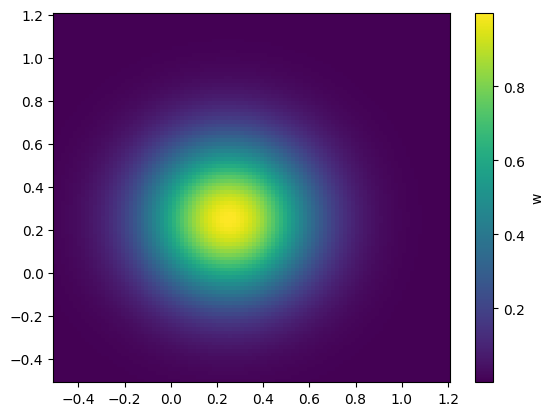

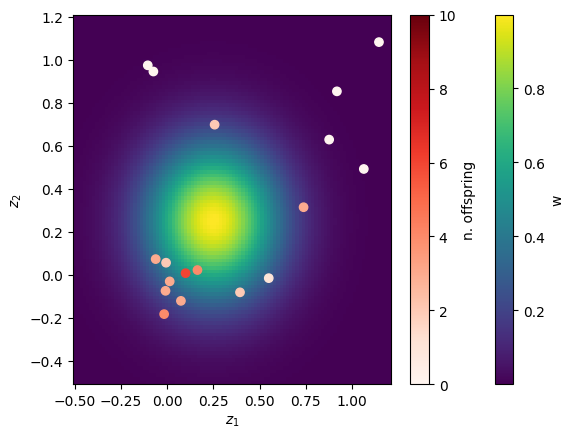

In [95]:
# Make meshgrid
X, Y = np.meshgrid(np.linspace(-0.5,1.2,100), np.linspace(-0.5,1.2,100))

# Flatten to feed into fit_gaus
z2 = np.column_stack([X.ravel(), Y.ravel()])

# Evaluate w2
w2_g = hanoi.fit_gaus(z_opt=np.array([0.25, 0.25], dtype=np.float64),
                    sigma=0.25,
                    z=z2)

# Reshape to grid for pcolormesh
w2_g_grid = w2_g.reshape(100, 100)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')


fig, ax = plt.subplots()

# Static scatter (background)
sc_bg = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(sc_bg, ax=ax, label='w')
# Moving scatter (foreground)
vmin = gens.n_offspring.min()
vmax = gens.n_offspring.max()
sc_fg = ax.scatter(
    gens.phenotype[0, :, 0],
    gens.phenotype[0, :, 1],
    c=gens.n_offspring[0],
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(sc_fg, ax=ax, label='n. offspring')

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')

def update(i):
    sc_fg.set_offsets(gens.phenotype[i])  # update positions
    sc_fg.set_array(gens.n_offspring[i])  # update colours
    return sc_fg,

anim = FuncAnimation(fig, update, frames = gens.n_gen-1, interval = 500, blit = True)

In [96]:
HTML(anim.to_jshtml())

Also, how distribution of breeding value changed over generations can be visualised.

In [97]:
def plot_bivariate_normal_contour(mean, cov, percentile=0.95, ax=None, **ellipse_kwargs):
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]  # descending
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Rotation angle of ellipse
    angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))

    # Chi-square scaling for desired percentile
    s = chi2.ppf(percentile, df=2)

    # Width and height 
    width, height = 2 * np.sqrt(eigvals * s)

    if ax is None:
        fig, ax = plt.subplots()

    # Create and add ellipse
    ellipse = Ellipse(mean, width=width, height=height, angle=angle, **ellipse_kwargs)
    ax.add_patch(ellipse)
    
    return ellipse   # return the patch, not ax


In [98]:
contours = []

def update(i):
    sc_fg.set_offsets(gens.breed_val[i].mean.T)

    global contours
    # remove old ellipses
    for e in contours:
        e.remove()
    contours = []

    # add new ellipses
    for j in range(gens.breed_val[i].mean.shape[1]):
        mean = z_ref + gens.breed_val[i].mean[:, j]
        cov = c_ref + gens.breed_val[i].varcov[j]
        e = plot_bivariate_normal_contour(mean, cov, ax=ax, edgecolor='tab:orange', facecolor='none')
        contours.append(e)

    return [sc_fg] + contours


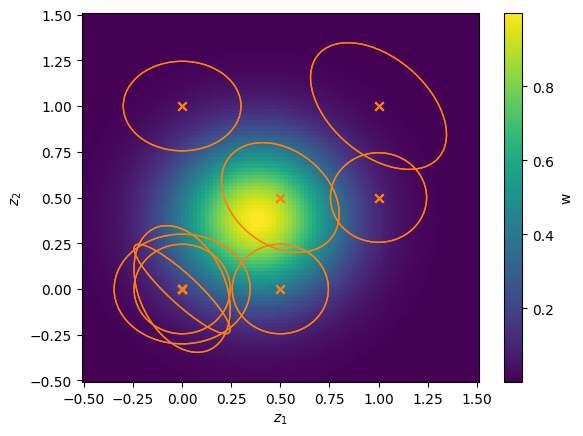

In [99]:
# Make meshgrid
X, Y = np.meshgrid(np.linspace(-0.5,1.5,100), np.linspace(-0.5,1.5,100))

fig, ax = plt.subplots()

# Flatten to feed into fit_gaus
z2 = np.column_stack([X.ravel(), Y.ravel()])

# Evaluate w2
w2_g = hanoi.fit_gaus(z_opt=np.array([0.25, 0.25], dtype=np.float64),
                    sigma=0.25,
                    z=z2)


# Draw tiled background
sc_bg = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(sc_bg, ax=ax, label='w')

# --- Moving points (foreground) ---
sc_fg = ax.scatter(
    gens.breed_val[0].mean.T[:, 0],
    gens.breed_val[0].mean.T[:, 1],
    c='tab:orange',
    marker='x'
)

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')

# --- Track ellipses ---
contours = []

def update(i):
    # Update moving points
    sc_fg.set_offsets(gens.breed_val[i].mean.T)

    # Remove old ellipses
    global contours
    for e in contours:
        e.remove()
    contours = []

    # Add new ellipses
    for j in range(gens.breed_val[i].mean.shape[1]):
        mean = z_ref + gens.breed_val[i].mean[:, j]
        cov = c_ref + gens.breed_val[i].varcov[j]
        e = plot_bivariate_normal_contour(
            mean, cov,
            percentile=0.95,
            ax=ax,
            edgecolor='tab:orange',
            facecolor='none'
        )
        contours.append(e)

    return [sc_fg] + contours

# --- Animate ---
anim = FuncAnimation(fig, update, frames=gens.n_gen, interval=500, blit=False)

In [100]:
HTML(anim.to_jshtml())

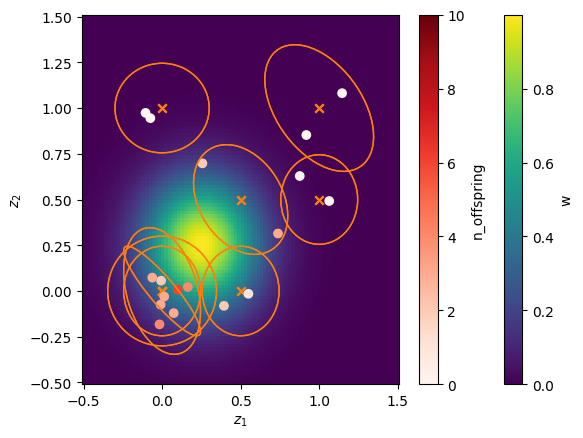

In [101]:
# Make meshgrid
X, Y = np.meshgrid(np.linspace(-0.5,1.5,100), np.linspace(-0.5,1.5,100))

fig, ax = plt.subplots()

# Flatten to feed into fit_gaus
z2 = np.column_stack([X.ravel(), Y.ravel()])

# Evaluate w2
w2_g = hanoi.fit_gaus(z_opt=np.array([0.25, 0.25], dtype=np.float64),
                    sigma=0.25,
                    z=z2)

# Reshape to grid for pcolormesh
w2_g_grid = w2_g.reshape(100, 100)

# Draw tiled background
sc_bg = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(sc_bg, ax=ax, label='w')


# --- Moving points: breeding values (orange x) ---
sc_fg_bv = ax.scatter(
    gens.breed_val[0].mean.T[:, 0],
    gens.breed_val[0].mean.T[:, 1],
    c='tab:orange',
    marker='x'
)

# --- Moving points: phenotype colored by n_offspring ---
vmin = gens.n_offspring.min()
vmax = gens.n_offspring.max()
sc_fg_pheno = ax.scatter(
    gens.phenotype[0, :, 0],
    gens.phenotype[0, :, 1],
    c=gens.n_offspring[0],
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(sc_fg_pheno, ax=ax, label='n_offspring')

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')

# --- Track ellipses ---
contours = []

def update(i):
    # Update breeding value points
    sc_fg_bv.set_offsets(gens.breed_val[i].mean.T)

    # Update phenotype points and colors
    sc_fg_pheno.set_offsets(gens.phenotype[i])
    sc_fg_pheno.set_array(gens.n_offspring[i])

    # Remove old ellipses
    global contours
    for e in contours:
        e.remove()
    contours = []

    # Add new ellipses for breeding values
    for j in range(gens.breed_val[i].mean.shape[1]):
        mean = z_ref + gens.breed_val[i].mean[:, j]
        cov = c_ref + gens.breed_val[i].varcov[j]
        e = plot_bivariate_normal_contour(
            mean, cov,
            percentile=0.95,
            ax=ax,
            edgecolor='tab:orange',
            facecolor='none'
        )
        contours.append(e)

    return [sc_fg_bv, sc_fg_pheno] + contours

# --- Animate ---
anim = FuncAnimation(fig, update, frames=gens.n_gen, interval=500, blit=False)

In [102]:
HTML(anim.to_jshtml())

In [103]:
z_ref

array([0., 0.])

In [104]:
M.mean

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])